# Probability & Statistics Lab 1: Naive Bayes Classifier

**Work breakdown:**
-   *Dovhai Yulia* data preprocessing and visualization
-   *Voskalo Liubomyr* implementation of a Unigram Naive Bayes classifier and it's evaluation
-   *Yakymashchenko Artem* additional task (Bigram Naive Bayes classifier) and conclusion 

## Introduction

During the first three weeks, you learned a couple of essential notions
and theorems, and one of the most important among them is the **Bayes
theorem**:

$$
\mathsf P(A \mid B) = \frac{\mathsf P(A)\mathsf P(B \mid A)}{\mathsf P(B)}.
$$


**Naive Bayes Classifier** is a simple algorithm, which is based on
Bayes theorem and used for solving classification problems.

**Classification problem** is a problem in which an observation has to
be classified in one of the $n$ classes based on its similarity with
observations in each class.

It is a **probabilistic classifier**, which means it predicts based on
the probability of an observation belonging to each class. To compute
it, this algorithm uses **Bayes' formula** as:
$$
\mathsf P (\text{class}_i \mid \text{observation}) = \frac{\mathsf P(\text{class}_i) \mathsf P(\text{observation} \mid \text{class}_i)}{\mathsf P(\text{observation})}. \quad \quad (1)
$$
Breaking down the pieces of the formula,
- $\mathsf P(\text{class}_i)$ is referred to as a **prior** [distribution]: it provides initial class probabilities, influenced by prior beliefs about the problem.
- $\mathsf P(\text{observation} \mid \text{class}_i)$ is the **likelihood**: it tells how likely observations are for a chosen class.
- $\mathsf P(\text{observation})$ is the **evidence**; usually isn't computed directly and used as a normalization constant s.t. sum of $\mathsf P (\text{class}_i \mid \text{observation})$ for all classes is $1$.


This lab focuses on binary classification of text. Text can be considered a sequence of observations/features, with many ways to split it into individual/elementary features. Here, we split the text by words, and one word is considered a feature $\text{feature}_j$:
$\mathsf P(\text{text}) = \mathsf P(\text{features}_1, \text{feature}_2, \dots, \text{feature}_N) = \mathsf P(\text{features}_1)\cdot \mathsf P(\text{feature}_2 \mid \text{feature}_1) \cdot \mathsf P(\text{feature}_3 \mid (\text{feature}_1, \text{feature}_2)) \dots.$

However, modeling such long conditionals is complex, compute-intensive, and requires lots of data.

One way to deal with this is to assume independence, where one can write: $\mathsf P(\text{text}) = \prod_{j=1}^N \mathsf P(\text{feature}_j).$
Or, one could assume the dependence only on the previous word, which will be explored in the additional task!

$\mathsf P(\text{feature}_j)$ is unknown, and we estimate it empirically using the training data split. The empirical probability of some feature $x$ would be $\frac{\text{\# of } x}{\text{total \# of features}}.$
Note that such an approach would turn $\mathsf P(\text{text})$ to $0$ for any completely new feature (as its count among data is zero), which is undesirable.
A common way to deal with this is [Laplace smoothing](https://en.wikipedia.org/wiki/Additive_smoothing). No need to dive deeply into this now, as you will develop a better intuition as you progress through the course.
In this lab, you shall apply Laplace smoothing to both class priors and feature ($\log$–)probabilities.

#### Implementation note

Instead of storing and calculating probabilities directly, many ML solutions prefer computations in $\log$ domain. One of the reasons is numerical stability, which shows up in $\prod_{j=1}^N \mathsf P(\text{feature}_j)$:
each $\mathsf P(\text{feature}_j) \in (0, 1)$ in practice, resulting in tiny final product, which floating-point numbers the computer uses can't store as accurately.
However, in the logarithmic domain even $10^{-100}$ corresponds to an order of magnitude of $-100$.

So, let's rewrite the equation we estimate:
$$
\log [\mathsf P (\text{class}_i \mid \text{observation})] = \underbrace{\log[\mathsf P(\text{class}_i)] + \sum_{j=1}^N \log[\mathsf P(\text{feature}_j)]}_{\text{used to be a numerator, } L_i} - \overbrace{\log[\mathsf P(\text{observation})]}^{\text{used to be a denominator, log-evidence}}. \quad \quad (2)
$$


[A video example of a Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA).


### Outline of the work

1.  **Data preprocessing** (1 point)
2.  **Data visualization** (1 point)
3.  **Classifier implementation from scratch** (1.5 points)
4.  **Measurements of effectiveness of your classifier** (1.5 points)
5.  **Additional task** (up to 2 points, optional)


*Please submit a pre-executed `.ipynb` notebook for easier evaluation.*


### Data preprocessing

In [299]:
import pathlib
import pandas as pd
import numpy as np
import re
from collections import defaultdict


class Dataset:
    def __init__(self, dataset_dir_path: pathlib.Path):
        self.train_df = pd.read_csv(dataset_dir_path / "train.csv")
        self.test_df = pd.read_csv(dataset_dir_path / "test.csv")

        self.bag_of_words_per_label_id: dict[int, dict[str, int]] = {}
        self.bag_of_log_probabilities_per_label_id: dict[int, dict[str, float]] = {}

        self.label_to_id: dict[str, int] = {}
        self.id_to_label: dict[int, str] = {}
        self.log_priors: np.ndarray = np.array([])
        self.unseen_log_prob_per_label: dict[int, float] = {}

    def preprocess_text(self, stop_words: list[str]) -> None:
        """
        Adds "label-id" (starting with 0) and "useful-words" columns to dataframes.
        Useful words are the ones that aren't in the stop words list.
        Remove the punctuation, map all the text to one register (e.g., lowercase).

        You may add custom preprocessing if it's justified!
        """
        # Build label-to-id mapping from training labels
        unique_labels = self.train_df["label"].unique().tolist()
        unique_labels.sort()  # deterministic ordering
        self.label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
        self.id_to_label = {idx: label for label, idx in self.label_to_id.items()}

        stop_words_set = set(stop_words)

        for df in [self.train_df, self.test_df]:
            # Add label-id column
            df["label-id"] = df["label"].map(self.label_to_id)

            # Process each tweet: lowercase, remove punctuation, filter stop words
            useful_words_list = []
            for text in df["tweet"]:
                if not isinstance(text, str):
                    useful_words_list.append([])
                    continue
                text = text.lower()
                # Remove URLs
                text = re.sub(r'http\S+|www\S+', '', text)
                # Remove @user mentions
                text = re.sub(r'@\w+', '', text)
                # Remove punctuation (keep only letters, digits, spaces)
                text = re.sub(r'[^a-z0-9\s]', '', text)
                words = text.split()
                # Filter stop words and very short words
                useful = [w for w in words if w not in stop_words_set and len(w) > 1]
                useful_words_list.append(useful)
            df["useful-words"] = useful_words_list


    def calculate_classes_prior(self, smoothing_alpha: float) -> np.ndarray:
        """
        :param smoothing_alpha: parameter of Laplace smoothing.
        :return: distribution of classes after smoothing, starting with label-id 0.
        """
        n_classes = len(self.label_to_id)
        class_counts = np.zeros(n_classes)
        for label_id in range(n_classes):
            class_counts[label_id] = (self.train_df["label-id"] == label_id).sum()

        # Laplace smoothing: (count + alpha) / (total + alpha * n_classes)
        smoothed = (class_counts + smoothing_alpha) / (class_counts.sum() + smoothing_alpha * n_classes)
        self.log_priors = np.log(smoothed)
        return smoothed

    def compute_bag_of_words(self) -> None:
        """
        Counts the number of occurrences of each word per label id and updates `self.bag_of_words_per_label_id`.

        Bag of words intro: https://machinelearningmastery.com/gentle-introduction-bag-words-model/.
        Advice: you may use `collections.defaultdict` (https://docs.python.org/3/library/collections.html#collections.defaultdict).
        """
        n_classes = len(self.label_to_id)
        for label_id in range(n_classes):
            self.bag_of_words_per_label_id[label_id] = defaultdict(int)

        for _, row in self.train_df.iterrows():
            label_id = row["label-id"]
            for word in row["useful-words"]:
                self.bag_of_words_per_label_id[label_id][word] += 1


    def compute_bag_of_log_probabilities(self, smoothing_alpha: float) -> dict:
        """
        Uses `self.bag_of_words_per_label_id` and updates `self.bag_of_log_probabilities_per_label_id`.
        `self.bag_of_log_probabilities_per_label_id` should store log[P(feature_j)].

        :param smoothing_alpha: parameter of Laplace smoothing.
        :return the log-probability of a new(previously unseen) feature per label, necessary for evaluation on the test set.
        """
        # Collect the full vocabulary across all classes
        vocab = set()
        for label_id in self.bag_of_words_per_label_id:
            vocab.update(self.bag_of_words_per_label_id[label_id].keys())
        vocab_size = len(vocab)

        unseen_log_prob = {}
        for label_id in self.bag_of_words_per_label_id:
            bow = self.bag_of_words_per_label_id[label_id]
            total_words = sum(bow.values())
            denominator = total_words + smoothing_alpha * (vocab_size + 1)  # +1 for unseen

            self.bag_of_log_probabilities_per_label_id[label_id] = {}
            for word in vocab:
                count = bow.get(word, 0)
                self.bag_of_log_probabilities_per_label_id[label_id][word] = np.log(
                    (count + smoothing_alpha) / denominator
                )

            # Log-probability for unseen words
            unseen_log_prob[label_id] = np.log(smoothing_alpha / denominator)

        self.unseen_log_prob_per_label = unseen_log_prob
        return unseen_log_prob

discrimination_dataset_path = pathlib.Path("data/discrimination")
discrimination_dataset = Dataset(discrimination_dataset_path)

labels = discrimination_dataset.train_df["label"].unique().tolist()
print(f"Labels are {labels}.")

Labels are ['discrim', 'neutral'].


Loading the stop words

In [300]:
stop_words_path = pathlib.Path("stop_words.txt")

stop_words: list[str] = []
with open(stop_words_path) as f:
    for line in f:
        stop_words.append(line.strip())

print(f"Some of the stop words are {stop_words[:8]}.")

Some of the stop words are ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am'].


In [301]:
discrimination_dataset.preprocess_text(stop_words)

In [302]:
classes_alpha = 1.0  # Laplace smoothing parameter for class priors
discrimination_dataset.calculate_classes_prior(classes_alpha)

array([0.07030482, 0.92969518])

In [303]:
discrimination_dataset.compute_bag_of_words()

In [304]:
features_alpha = 1  # Laplace smoothing parameter for features
unseen_feature_log_prob = discrimination_dataset.compute_bag_of_log_probabilities(features_alpha)

### Data visualization

Visualize the dataset, its properties, etc. You may use external libraries such as `matplotlib`, `plotly`, etc. Data analysis could provide hints/ideas for downstream classifier evaluation.

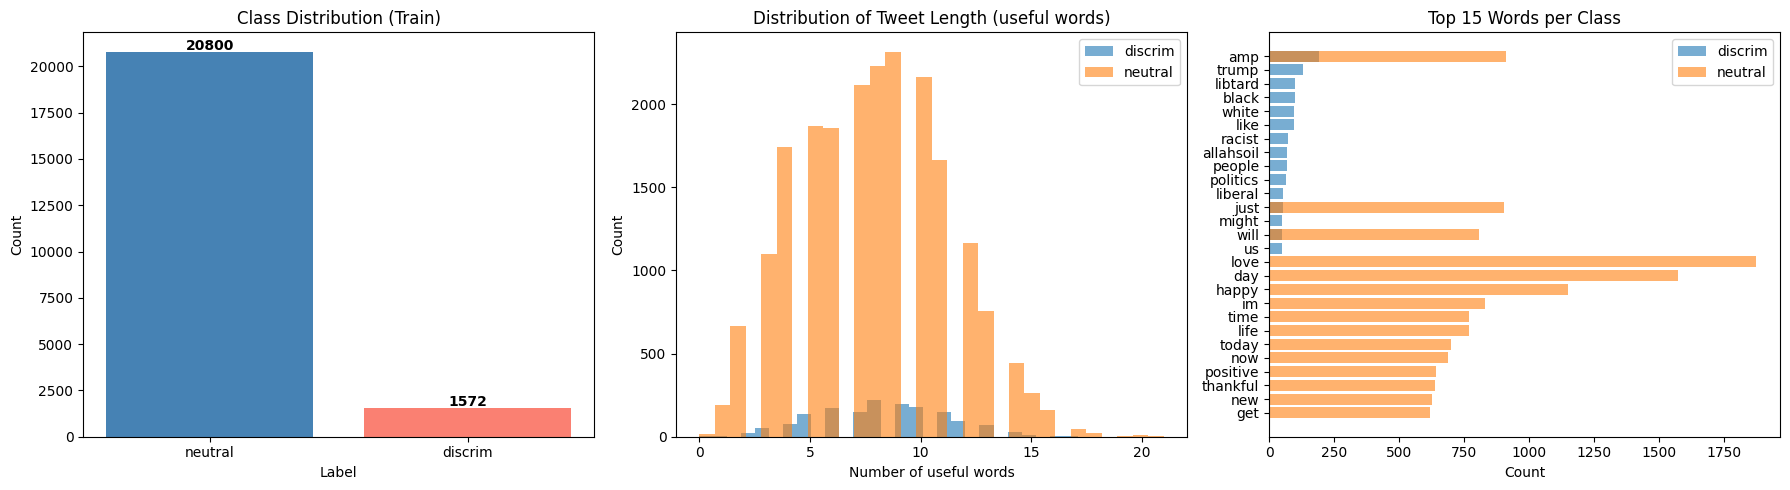

In [305]:
import matplotlib.pyplot as plt

# 1. Class distribution in training set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

class_counts = discrimination_dataset.train_df["label"].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Class Distribution (Train)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Distribution of tweet lengths (in useful words)
discrimination_dataset.train_df["text_length"] = discrimination_dataset.train_df["useful-words"].apply(len)
for label in discrimination_dataset.label_to_id:
    subset = discrimination_dataset.train_df[discrimination_dataset.train_df["label"] == label]
    axes[1].hist(subset["text_length"], bins=30, alpha=0.6, label=label)
axes[1].set_title("Distribution of Tweet Length (useful words)")
axes[1].set_xlabel("Number of useful words")
axes[1].set_ylabel("Count")
axes[1].legend()

# 3. Top 15 most frequent words per class
for label_id, label_name in discrimination_dataset.id_to_label.items():
    bow = discrimination_dataset.bag_of_words_per_label_id[label_id]
    sorted_words = sorted(bow.items(), key=lambda x: x[1], reverse=True)[:15]
    words, counts = zip(*sorted_words)
    axes[2].barh(words, counts, alpha=0.6, label=label_name)
axes[2].set_title("Top 15 Words per Class")
axes[2].set_xlabel("Count")
axes[2].legend()
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Classifier implementation

Recall equation $(2)$. You will manually calculate the *"used to be a numerator"* part, call it $L_i$, for each class, while log-evidence is numerically safely calculated from an array of log-domain per-class numerators.


In [306]:
def compute_log_evidence(per_label_log_domain_numerator: np.ndarray) -> float:
    return np.logaddexp.reduce(per_label_log_domain_numerator)

#### Derivation of log-evidence calculation

Assume all $L_i$ are calculated. Derive how one would calculate log-evidence. Later explain how it connects to the provided above `compute_log_evidence` function.

Hint: use the property of valid probability distributions.

---

**Derivation:**

From Bayes' theorem (equation 1), the posterior for each class is:

$$
\mathsf P(\text{class}_i \mid \text{obs}) = \frac{\mathsf P(\text{class}_i) \cdot \mathsf P(\text{obs} \mid \text{class}_i)}{\mathsf P(\text{obs})}
$$

Since the posterior is a valid probability distribution, it must sum to 1 over all classes:

$$
\sum_i \mathsf P(\text{class}_i \mid \text{obs}) = 1
$$

Substituting Bayes' formula:

$$
\sum_i \frac{\mathsf P(\text{class}_i) \cdot \mathsf P(\text{obs} \mid \text{class}_i)}{\mathsf P(\text{obs})} = 1
$$

Solving for the evidence:

$$
\mathsf P(\text{obs}) = \sum_i \mathsf P(\text{class}_i) \cdot \mathsf P(\text{obs} \mid \text{class}_i)
$$

Define the log-domain numerator for class $i$ as:

$$
L_i = \log[\mathsf P(\text{class}_i)] + \sum_{j=1}^N \log[\mathsf P(\text{feature}_j \mid \text{class}_i)] = \log[\mathsf P(\text{class}_i) \cdot \mathsf P(\text{obs} \mid \text{class}_i)]
$$

So $\mathsf P(\text{class}_i) \cdot \mathsf P(\text{obs} \mid \text{class}_i) = e^{L_i}$, and the evidence becomes:

$$
\mathsf P(\text{obs}) = \sum_i e^{L_i}
$$

Taking the logarithm:

$$
\log[\mathsf P(\text{obs})] = \log\left(\sum_i e^{L_i}\right)
$$

**Connection to `compute_log_evidence`:**

The function `compute_log_evidence` uses `np.logaddexp.reduce(...)`, which computes exactly $\log\left(\sum_i e^{L_i}\right)$ in a numerically stable way. For two values $a$ and $b$, `logaddexp(a, b)` computes $\log(e^a + e^b)$ without explicitly computing the potentially very large or very small exponentials. The `.reduce` operation chains this across all elements of the array:

$$
\texttt{logaddexp.reduce}([L_0, L_1, \ldots, L_{C-1}]) = \log(e^{L_0} + e^{L_1} + \ldots + e^{L_{C-1}}) = \log[\mathsf P(\text{obs})]
$$

This is numerically stable because it avoids computing tiny exponentials that could underflow to zero.

#### Prediction implementation

In [307]:
from typing import Literal


def predict(dataset: Dataset, split: Literal["train", "test"]) -> np.ndarray:
    """
    "train" split option may be useful for debugging.
    :return: the (NxC) array of predicted probabilities, where N is the number of texts, and C is the number of classes.
    """
    if split == "train":
        df = dataset.train_df
    else:
        df = dataset.test_df

    n_classes = len(dataset.label_to_id)
    predicted_probabilities = []

    for _, row in df.iterrows():
        words = row["useful-words"]

        # Compute L_i for each class: log P(class_i) + sum of log P(feature_j | class_i)
        log_numerators = np.zeros(n_classes)
        for label_id in range(n_classes):
            log_numerators[label_id] = dataset.log_priors[label_id]
            log_probs = dataset.bag_of_log_probabilities_per_label_id[label_id]
            unseen_lp = dataset.unseen_log_prob_per_label[label_id]
            for word in words:
                log_numerators[label_id] += log_probs.get(word, unseen_lp)

        # Compute log-evidence and then posterior probabilities
        log_evidence = compute_log_evidence(log_numerators)
        log_posteriors = log_numerators - log_evidence
        posteriors = np.exp(log_posteriors)

        predicted_probabilities.append(posteriors)

    return np.array(predicted_probabilities)

In [308]:
# Run prediction on train and test sets
train_predictions = predict(discrimination_dataset, "train")
test_predictions = predict(discrimination_dataset, "test")

print(f"Train predictions shape: {train_predictions.shape}")
print(f"Test predictions shape: {test_predictions.shape}")
print(f"\nLabel mapping: {discrimination_dataset.label_to_id}")
print(f"\nSample predictions (first 5 test examples):")
print(test_predictions[:5])

Train predictions shape: (22372, 2)
Test predictions shape: (9589, 2)

Label mapping: {'discrim': 0, 'neutral': 1}

Sample predictions (first 5 test examples):
[[7.48497958e-03 9.92515020e-01]
 [9.96865290e-01 3.13470963e-03]
 [1.66157327e-02 9.83384267e-01]
 [9.56972015e-03 9.90430280e-01]
 [1.26237050e-08 9.99999987e-01]]


### Classifier evaluation

Note that accuracy is not always a good metric for the classifier. One may look at precision and recall curves, F1 score metric, ROC curves.

When evaluating the model, it's important to understand the
different types of classification results:

-   A ***true positive***(TP) result is one where the model correctly
    predicts the positive class.
-   A ***true negative***(TN) result is one where the model correctly
    predicts the negative class.
-   A ***false positive***(FP) result is one where the model incorrectly
    predicts the positive class when it is actually negative.
-   A ***false negative***(FN) result is one where the model incorrectly
    predicts the negative class when it is actually positive.

Precision measures the proportion of true positive predictions among all positive predictions made by the model: $\text{Precision} = \frac{TP}{TP+FP}.$

Recall measures the proportion of true positives identified out of all actual positive cases: $\text{Recall} = \frac{TP}{TP+FN}$.


F1 score is the harmonic mean of both precision and recall: $\text{F1} = \frac{2\times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.$

See [this link](https://cohere.com/blog/classification-eval-metrics) to find more information about metrics.

Visualize plots and show failure cases.

In [309]:
# --- Task 3: Precision, Recall, F1-score, ROC curve, Precision-Recall curve ---

# Ground truth labels for the test set
y_true = discrimination_dataset.test_df["label-id"].values
y_pred = np.argmax(test_predictions, axis=1)

# We treat "discrim" as the positive class
positive_label_id = discrimination_dataset.label_to_id["discrim"]
negative_label_id = discrimination_dataset.label_to_id["neutral"]

print(f"Positive class ('discrim') id: {positive_label_id}")
print(f"Negative class ('neutral') id: {negative_label_id}")

# Compute TP, TN, FP, FN
TP = np.sum((y_pred == positive_label_id) & (y_true == positive_label_id))
TN = np.sum((y_pred == negative_label_id) & (y_true == negative_label_id))
FP = np.sum((y_pred == positive_label_id) & (y_true == negative_label_id))
FN = np.sum((y_pred == negative_label_id) & (y_true == positive_label_id))

print(f"\nConfusion Matrix:")
print(f"  TP={TP}, FP={FP}")
print(f"  FN={FN}, TN={TN}")

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Positive class ('discrim') id: 0
Negative class ('neutral') id: 1

Confusion Matrix:
  TP=421, FP=391
  FN=250, TN=8527

Accuracy:  0.9332
Precision: 0.5185
Recall:    0.6274
F1-score:  0.5678


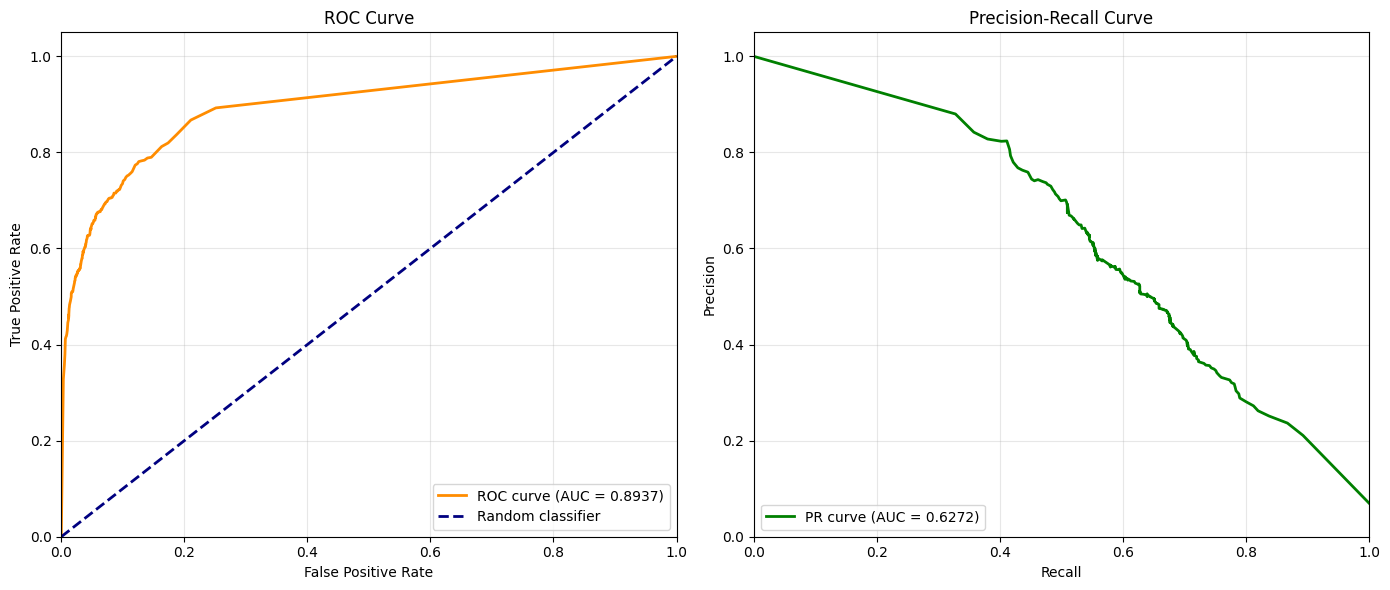

In [310]:
# --- ROC Curve ---
# Probability of the positive class ("discrim")
y_scores = test_predictions[:, positive_label_id]

# Compute ROC curve manually
thresholds_roc = np.linspace(0, 1, 200)
tpr_list = []
fpr_list = []

for thresh in thresholds_roc:
    y_pred_thresh = (y_scores >= thresh).astype(int)
    # Map: 1 -> positive_label_id, 0 -> negative_label_id
    # Since we are thresholding on positive class probability:
    tp = np.sum((y_pred_thresh == 1) & (y_true == positive_label_id))
    fp = np.sum((y_pred_thresh == 1) & (y_true == negative_label_id))
    fn = np.sum((y_pred_thresh == 0) & (y_true == positive_label_id))
    tn = np.sum((y_pred_thresh == 0) & (y_true == negative_label_id))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr_list.append(tpr)
    fpr_list.append(fpr)

# Compute AUC using trapezoidal rule (sort by FPR)
sorted_indices = np.argsort(fpr_list)
fpr_sorted = np.array(fpr_list)[sorted_indices]
tpr_sorted = np.array(tpr_list)[sorted_indices]
auc_roc = np.trapezoid(tpr_sorted, fpr_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC curve
axes[0].plot(fpr_sorted, tpr_sorted, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall Curve ---
precision_list = []
recall_list = []

for thresh in thresholds_roc:
    y_pred_thresh = (y_scores >= thresh).astype(int)
    tp = np.sum((y_pred_thresh == 1) & (y_true == positive_label_id))
    fp = np.sum((y_pred_thresh == 1) & (y_true == negative_label_id))
    fn = np.sum((y_pred_thresh == 0) & (y_true == positive_label_id))

    p = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_list.append(p)
    recall_list.append(r)

# Compute AUC-PR
sorted_indices_pr = np.argsort(recall_list)
recall_sorted = np.array(recall_list)[sorted_indices_pr]
precision_sorted = np.array(precision_list)[sorted_indices_pr]
auc_pr = np.trapezoid(precision_sorted, recall_sorted)

# Plot Precision-Recall curve
axes[1].plot(recall_sorted, precision_sorted, color='green', lw=2, label=f'PR curve (AUC = {auc_pr:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Error Analysis (Failure Cases)

In [311]:
# --- Task 4: Failure case analysis ---

# Find misclassified examples
test_df = discrimination_dataset.test_df.copy()
test_df["predicted_label_id"] = y_pred
test_df["predicted_label"] = test_df["predicted_label_id"].map(discrimination_dataset.id_to_label)
test_df["prob_discrim"] = test_predictions[:, positive_label_id]
test_df["prob_neutral"] = test_predictions[:, negative_label_id]
test_df["correct"] = test_df["label-id"] == test_df["predicted_label_id"]

misclassified = test_df[~test_df["correct"]]

print(f"Total test samples: {len(test_df)}")
print(f"Misclassified samples: {len(misclassified)}")
print(f"Error rate: {len(misclassified)/len(test_df)*100:.2f}%")
print()

# Count errors by type
false_positives = misclassified[misclassified["predicted_label_id"] == positive_label_id]
false_negatives = misclassified[misclassified["predicted_label_id"] == negative_label_id]
print(f"False Positives (neutral predicted as discrim): {len(false_positives)}")
print(f"False Negatives (discrim predicted as neutral): {len(false_negatives)}")

Total test samples: 9589
Misclassified samples: 641
Error rate: 6.68%

False Positives (neutral predicted as discrim): 391
False Negatives (discrim predicted as neutral): 250


In [312]:
# Show examples of False Positives (neutral tweets classified as discriminatory)
print("=" * 80)
print("FALSE POSITIVES: Neutral tweets misclassified as Discriminatory")
print("=" * 80)
for i, (_, row) in enumerate(false_positives.head(5).iterrows()):
    print(f"\n--- Example {i+1} ---")
    print(f"Tweet: {row['tweet']}")
    print(f"True label: {row['label']}")
    print(f"Predicted: {row['predicted_label']}")
    print(f"P(discrim)={row['prob_discrim']:.4f}, P(neutral)={row['prob_neutral']:.4f}")
    print(f"Useful words: {row['useful-words']}")

FALSE POSITIVES: Neutral tweets misclassified as Discriminatory

--- Example 1 ---
Tweet: @user @user @user @user   with the allocation of 1.127tn to justice law&amp;order. no more "kintu kidogo"
True label: neutral
Predicted: discrim
P(discrim)=0.9969, P(neutral)=0.0031
Useful words: ['allocation', '1127tn', 'justice', 'lawamporder', 'kintu', 'kidogo']

--- Example 2 ---
Tweet: porait of femi festus  ____________________________________  #porait #poraitmag  â¦
True label: neutral
Predicted: discrim
P(discrim)=0.6342, P(neutral)=0.3658
Useful words: ['porait', 'femi', 'festus', 'porait', 'poraitmag']

--- Example 3 ---
Tweet: sumvah..kagak bisa move-on gara2 nonton clannad after story t,t salut #anime #otaku #clannad #clannadafterstory   #animelovers
True label: neutral
Predicted: discrim
P(discrim)=0.9973, P(neutral)=0.0027
Useful words: ['sumvahkagak', 'bisa', 'moveon', 'gara2', 'nonton', 'clannad', 'story', 'tt', 'salut', 'anime', 'otaku', 'clannad', 'clannadafterstory', 'animelove

In [313]:
# Show examples of False Negatives (discriminatory tweets classified as neutral)
print("=" * 80)
print("FALSE NEGATIVES: Discriminatory tweets misclassified as Neutral")
print("=" * 80)
for i, (_, row) in enumerate(false_negatives.head(5).iterrows()):
    print(f"\n--- Example {i+1} ---")
    print(f"Tweet: {row['tweet']}")
    print(f"True label: {row['label']}")
    print(f"Predicted: {row['predicted_label']}")
    print(f"P(discrim)={row['prob_discrim']:.4f}, P(neutral)={row['prob_neutral']:.4f}")
    print(f"Useful words: {row['useful-words']}")

FALSE NEGATIVES: Discriminatory tweets misclassified as Neutral

--- Example 1 ---
Tweet: sexy cora porn  black girl porn
True label: discrim
Predicted: neutral
P(discrim)=0.0678, P(neutral)=0.9322
Useful words: ['sexy', 'cora', 'porn', 'black', 'girl', 'porn']

--- Example 2 ---
Tweet: 2017 a new beginning!! getting rid of this #nationdivider! good riddance pos!!
True label: discrim
Predicted: neutral
P(discrim)=0.3320, P(neutral)=0.6680
Useful words: ['2017', 'new', 'beginning', 'getting', 'rid', 'nationdivider', 'good', 'riddance', 'pos']

--- Example 3 ---
Tweet: @user and stop crying "bhakt bhakt" when you are cornered with no rational answer to offer. trust me read a book! it willâ¦ 
True label: discrim
Predicted: neutral
P(discrim)=0.0219, P(neutral)=0.9781
Useful words: ['stop', 'crying', 'bhakt', 'bhakt', 'cornered', 'rational', 'answer', 'offer', 'trust', 'read', 'book', 'will']

--- Example 4 ---
Tweet: you me too ððððð ð¹
True label: discrim
Predicted: neut

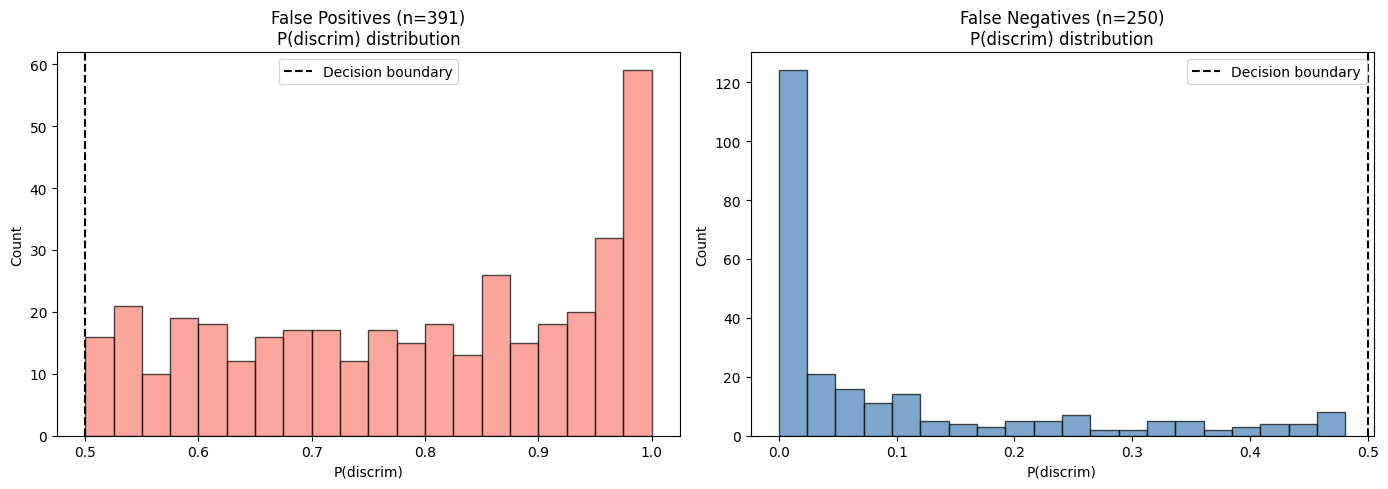

In [314]:
# Visualize error distribution: confidence of the model on misclassified examples
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predicted probability for misclassified samples
if len(false_positives) > 0:
    axes[0].hist(false_positives["prob_discrim"], bins=20, color="salmon", alpha=0.7, edgecolor='black')
    axes[0].set_title(f"False Positives (n={len(false_positives)})\nP(discrim) distribution")
    axes[0].set_xlabel("P(discrim)")
    axes[0].set_ylabel("Count")
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
    axes[0].legend()

if len(false_negatives) > 0:
    axes[1].hist(false_negatives["prob_discrim"], bins=20, color="steelblue", alpha=0.7, edgecolor='black')
    axes[1].set_title(f"False Negatives (n={len(false_negatives)})\nP(discrim) distribution")
    axes[1].set_xlabel("P(discrim)")
    axes[1].set_ylabel("Count")
    axes[1].axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
    axes[1].legend()

plt.tight_layout()
plt.show()

#### Error Analysis — Explanation

The model makes errors for several reasons:

1. **False Positives** (neutral → discrim): These typically occur when a neutral tweet contains words that frequently appear in discriminatory contexts (e.g., words related to religion, race, or ethnicity used in a neutral or positive context). The Naive Bayes model only considers individual word frequencies and cannot capture the overall sentiment or intent.

2. **False Negatives** (discrim → neutral): These occur when discriminatory tweets use indirect language, sarcasm, or common neutral words to express discrimination. Since the model relies on word frequency rather than context, subtle or veiled discrimination is missed.

3. **Naive independence assumption**: The model assumes all features (words) are conditionally independent given the class. This means it cannot capture phrases or word combinations (e.g., "not racist" would be treated the same as "racist" and "not" separately).

4. **Class imbalance**: The dataset is heavily imbalanced (many more neutral tweets than discriminatory ones), which can bias the model toward predicting the majority class.

### Additional task

You are asked to explore, implement, evaluate, and analyze another way to calculate $\mathsf P(\text{text})$; mainly, by conditioning on the previous feature:
$$
\mathsf P(\text{text}) = \prod_{j=2}^N \mathsf P(\text{feature}_j \mid \text{feature}_{j-1}).
$$

The task will be graded proportionally to analysis depth and conclusions viability.

In [315]:
# Bigram classifier class

class BigramNaiveBayes:
    def __init__(self, dataset, alpha: float = 1.0):
        self.dataset = dataset
        self.alpha = alpha

        self.bigram_counts: dict[int, dict[tuple[str, str], int]] = {}
        self.unigram_counts: dict[int, dict[str, int]] = {}

        self.vocab: set[str] = set()
        self.vocab_size: int = 0

    def fit(self):
        """
        Collects frequency of occurance for individual words (unigrams)
        and consecutive word pairs (bigrams) for each class in the training set
        """
        n_classes = len(self.dataset.label_to_id)

        for label_id in range(n_classes):
            self.bigram_counts[label_id] = {}
            self.unigram_counts[label_id] = {}

        # Iterate on all rows of the dataset
        for _, row in self.dataset.train_df.iterrows():
            label_id = row["label-id"]
            words = row["useful-words"]

            for i, word in enumerate(words):
                self.vocab.add(word)

                # unigrams
                current_unigram_count = self.unigram_counts[label_id].get(word, 0)
                self.unigram_counts[label_id][word] = current_unigram_count + 1

                # bigrams
                if i > 0:
                    bigram = (words[i - 1], words[i])
                    current_bigram_count = self.bigram_counts[label_id].get(
                        bigram, 0
                    )
                    self.bigram_counts[label_id][bigram] = (
                        current_bigram_count + 1
                    )

        self.vocab_size = len(self.vocab)


    def get_bigram_log_prob(self, w_prev: str, w_curr: str, label_id: int):
        """
        Calculates log P(w_curr | w_prev, class_i) using Laplace smoothing
        """
        count_bigram = self.bigram_counts[label_id].get((w_prev, w_curr), 0)
        count_unigram = self.unigram_counts[label_id].get(w_prev, 0)

        prob = (count_bigram + self.alpha) / (count_unigram + self.alpha * self.vocab_size)

        return np.log(prob)


    def predict(self, split: str = "test"):
        """
        Calculates the posterior probabilities of each text in the sample belonging to the classes
        :param split: "train" or "test"
        :return: an array of shape (N x C) containing class probabilities
        """
        if split == "train":
            df = self.dataset.train_df
        else:
            df = self.dataset.test_df

        n_classes = len(self.dataset.label_to_id)
        predictions = []

        for _, row in df.iterrows():
            words = row["useful-words"]
            log_numerators = np.zeros(n_classes)

            for label_id in range(n_classes):
                log_numerators[label_id] = self.dataset.log_priors[label_id]

                if len(words) == 0:
                    continue

                # Treat first word as a unigram
                first_word = words[0]
                unigram_probs = (
                    self.dataset.bag_of_log_probabilities_per_label_id[label_id]
                )

                unseen_lp = self.dataset.unseen_log_prob_per_label[label_id]
                log_numerators[label_id] += unigram_probs.get(
                    first_word, unseen_lp
                )

                # bigrams
                for j in range(1, len(words)):
                    log_numerators[label_id] += self.get_bigram_log_prob(
                        words[j - 1], words[j], label_id
                    )

            log_evidence = compute_log_evidence(log_numerators)
            log_posteriors = log_numerators - log_evidence
            predictions.append(np.exp(log_posteriors))

        return np.array(predictions)

************************************************************
Evaluation of bigram classifier
************************************************************
True Positives (TP):  245
True Negatives (TN):  8915
False Positives (FP): 3
False Negatives (FN): 426

Accuracy:  0.9553
Precision: 0.9879
Recall:    0.3651
F1-Score:  0.5332
ROC-AUC:   0.8660
PR-AUC:    0.5936
************************************************************


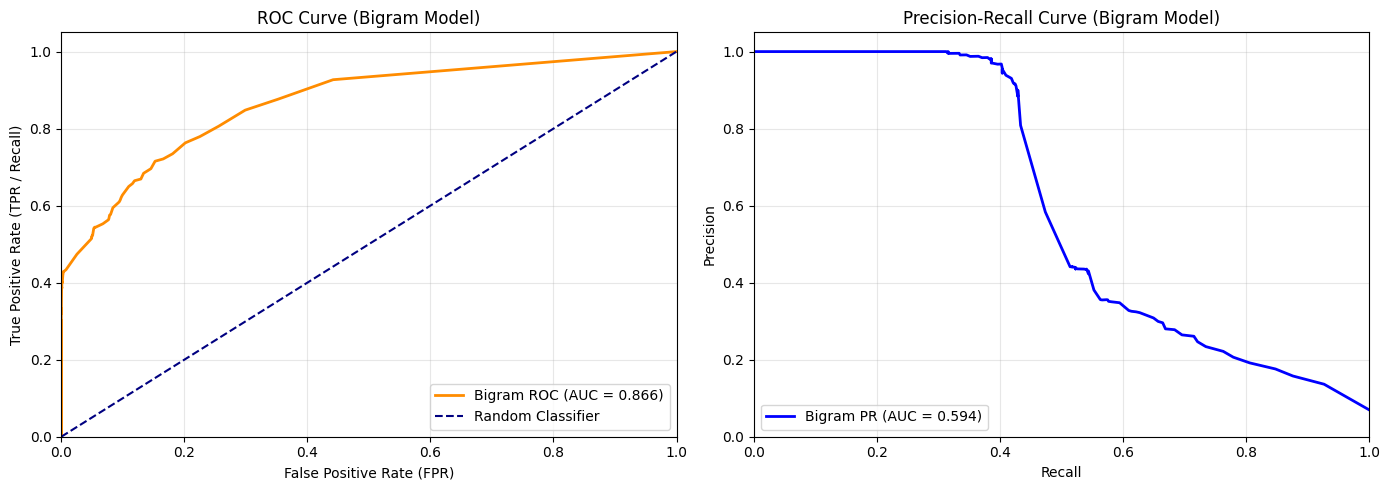

In [316]:
# Evaluating the model

bigram_model = BigramNaiveBayes(discrimination_dataset, alpha=1.0)
bigram_model.fit()

test_bigram_probs_all = bigram_model.predict(split="test")

positive_label_id = discrimination_dataset.label_to_id["discrim"]
negative_label_id = discrimination_dataset.label_to_id["neutral"]

y_true = discrimination_dataset.test_df["label-id"].values
y_scores = test_bigram_probs_all[:, positive_label_id]

# Confusion matrix
y_pred_default = (y_scores >= 0.5).astype(int)

# 1 - positive_label_id (discrim), 0 - negative_label_id (neutral)
tp = np.sum((y_pred_default == 1) & (y_true == positive_label_id))
fp = np.sum((y_pred_default == 1) & (y_true == negative_label_id))
fn = np.sum((y_pred_default == 0) & (y_true == positive_label_id))
tn = np.sum((y_pred_default == 0) & (y_true == negative_label_id))

accuracy = (tp + tn) / len(y_true)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = (
    (2 * precision * recall) / (precision + recall)
    if (precision + recall) > 0
    else 0.0
)


# calculating ROC curve and ROC-AUC using trapezoid method
thresholds_roc = np.linspace(0, 1, 200)
tpr_list = []
fpr_list = []

for thresh in thresholds_roc:
    y_pred_thresh = (y_scores >= thresh).astype(int)

    tp_i = np.sum((y_pred_thresh == 1) & (y_true == positive_label_id))
    fp_i = np.sum((y_pred_thresh == 1) & (y_true == negative_label_id))
    fn_i = np.sum((y_pred_thresh == 0) & (y_true == positive_label_id))
    tn_i = np.sum((y_pred_thresh == 0) & (y_true == negative_label_id))

    tpr = tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 0.0
    fpr = fp_i / (fp_i + tn_i) if (fp_i + tn_i) > 0 else 0.0

    tpr_list.append(tpr)
    fpr_list.append(fpr)


sorted_indices_roc = np.argsort(fpr_list)
fpr_sorted = np.array(fpr_list)[sorted_indices_roc]
tpr_sorted = np.array(tpr_list)[sorted_indices_roc]

auc_roc = np.trapezoid(tpr_sorted, fpr_sorted)


# calculate the PR curve and PR-AUC
thresholds_pr = np.linspace(0, 1, 200)
precision_list = []
recall_list = []

for thresh in thresholds_pr:
    y_pred_thresh = (y_scores >= thresh).astype(int)

    tp_i = np.sum((y_pred_thresh == 1) & (y_true == positive_label_id))
    fp_i = np.sum((y_pred_thresh == 1) & (y_true == negative_label_id))
    fn_i = np.sum((y_pred_thresh == 0) & (y_true == positive_label_id))

    prec_i = tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0
    rec_i = tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 0.0

    precision_list.append(prec_i)
    recall_list.append(rec_i)

sorted_indices_pr = np.argsort(recall_list)
recall_sorted = np.array(recall_list)[sorted_indices_pr]
precision_sorted = np.array(precision_list)[sorted_indices_pr]

auc_pr = np.trapezoid(precision_sorted, recall_sorted)


print("*" * 60)
print("Evaluation of bigram classifier")
print("*" * 60)
print(f"True Positives (TP):  {tp}")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}\n")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc_roc:.4f}")
print(f"PR-AUC:    {auc_pr:.4f}")
print("*" * 60)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(
    fpr_sorted,
    tpr_sorted,
    color="darkorange",
    lw=2,
    label=f"Bigram ROC (AUC = {auc_roc:.3f})",
)
axes[0].plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=1.5,
    linestyle="--",
    label="Random Classifier",
)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR / Recall)")
axes[0].set_title("ROC Curve (Bigram Model)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR curve
axes[1].plot(
    recall_sorted,
    precision_sorted,
    color="blue",
    lw=2,
    label=f"Bigram PR (AUC = {auc_pr:.3f})",
)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (Bigram Model)")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusions for additional task

In additional task we implemented bigram naive Bayes classifier. Unlike unigram classifier, this one relies on not only one word in the text, but two words in the row. So this classifier can see the difference between "hate you" and "you hate", when in the previous classifier this would be the same thing. 

Evaluation of the model showed that this model has high (98.79%) precision (low False Position count), but a low (36.51%) recall (high False Negative count). This means that bigram model is "too scared" to tell that a tweet is racist, so it makes almost no mistakes classifing neutral tweets, yet it also classifies most discriminating tweets as neutral. Also F1 score is slightly worse than in unigram model (53.32% vs 56.78%)

The sharp drop in the PR curve beyond ~0.42 marks the boundary where high confidence bigram matches end. As the decision threshold is lowered, False Positives accumulate rapidly relative to True Positives, causing Precision to degrade under severe class imbalance.

In conclusion we can say that unigram model works good with separate words, but can not relate them. Yet at the same bigram model cathes this difference, but suffers from the lack of vocabulary (we may encouter phrase "hate you" a couple of times in training, but we would know waht "you hate" means in testing data). So if we had a much bigger dataset, bigram model would have performed better than unigram one.  

### Overal conclusions

Summarize your work by explaining in a few sentences the points listed
below.

- Describe the method implemented in general. Show what are
    mathematical foundations you are basing your solution on.
- List pros and cons of the method. This should include the
    limitations of your method, all the assumption you make about the
    nature of your data etc.
- Explain why accuracy is not a good choice for the base metrics for
    classification tasks. Why is F1 score generally preferable?

# Our counclusions

### 1. Implemented Method & Mathematical Foundations
In this laboratory work, we implemented a Multinomial Naive Bayes Classifier for binary text classification to detect discriminatory content in tweets. The core mathematical foundation is **Bayes' Theorem**:

$$\mathsf P(\text{class}_i \mid \text{text}) = \frac{\mathsf P(\text{class}_i) \cdot \mathsf P(\text{text} \mid \text{class}_i)}{\mathsf P(\text{text})}$$

To make computation possible, the model relies on the **Naive Conditional Independence Assumption**, assuming that individual words (unigrams) occur independently of one another given the class label:

$$\mathsf P(\text{text} \mid \text{class}_i) = \prod_{j=1}^N \mathsf P(\text{word}_j \mid \text{class}_i)$$

To prevent numerical underflow caused by multiplying very small probabilities, all calculations were performed in the **logarithmic domain**. Furthermore, **Laplace Smoothing** ($\alpha = 1.0$) was incorporated into the conditional word distributions to handle unseen vocabulary in the test set and prevent zero-probability issues.


### 2. Method Pros, Cons, Limitations & Assumptions
* **Data Assumptions:** 
  * The dataset is assumed to be representable as a unordered "Bag of Words" (for Unigram) or 1st-order Markov chain (for Bigram).
  * Features (words) are assumed conditionally independent given the class label.

* **Pros:**
  * **High Computational Efficiency:** Extremely fast training and prediction times with minimal memory overhead.

* **Cons & Limitations:**
  * **Loss of Context:** The naive independence assumption ignores word order, grammar, and complex syntactic relationships (e.g., negation or sarcasm).
  * **Data Sparsity in Higher N-grams:** As seen in the Bigram extension, conditioning on previous words significantly increases dictionary size, leading to vocabulary sparsity and lower recall on unseen test phrases.


### 3. Metric Evaluation
* **The Flaw of Accuracy:**
  Accuracy calculates the proportion of correct predictions over total predictions: $\frac{TP + TN}{TP + TN + FP + FN}$. In our dataset, neutral tweets overwhelmingly outnumber discriminatory tweets (~93% neutral vs ~7% discriminatory). A naive dummy classifier that predicts "neutral" for every single tweet would achieve **~93% Accuracy** while failing to identify a single discriminatory tweet. Therefore, Accuracy is heavily skewed by the majority class ($TN$) and provides a false sense of model quality.
* **Superiority of F1-Score & PR-AUC:**
  * **F1-Score** takes into consideration Precision and Recall: $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$. It completely excludes True Negatives ($TN$) from its calculation, forcing the evaluation to focus exclusively on how effectively the model detects the minority (positive) class.
  * **PR-AUC (Precision-Recall Area Under Curve)** evaluates model trade-offs across all confidence thresholds without being inflated by a large $TN$ count, making it the most reliable evaluation metric for highly imbalanced text classification tasks.


### 4. Comparative Model Summary
* **Unigram Model:** Achieved $\text{ROC-AUC} = 0.8937$ and $\text{PR-AUC} = 0.6272$. It provided broader coverage and better generalization across test samples.
* **Bigram Model:** Achieved $\text{ROC-AUC} = 0.8660$ and $\text{PR-AUC} = 0.5936$. While it achieved higher precision on exact phrase matches, severe data sparsity caused a drop in recall and lower overall area under the curve.


### 5. Testing different alphas in Laplace smoothing
We also tested performance of the unigram and bigram models when **alpha < 1 or > 1**. Here are some F1 scores:

*unigram and bigram scores respectivly* <br>
alpha = 0.01: 0.5676, 0.5374 <br>
*alpha = 0.25*: 0.5256, 0.5602 *(the best for bigrans)*<br>
alpha = 0.5: 0.5439, 0.5515 <br>
**alpha = 1**: 0.5678, 0.5332 *(the standart and the best for unigrams)*<br>
alpha = 2: 0.5439, 0.5028 <br>
alpha = 5: 0.3927, 0.4178 <br>
alpha = 10: 0.2347, 0.3661 <br>
alpha = 100: 0.0000, 0.2951


* **alpha = 1.0 vs. alpha = 0.25:**
  * **Unigram Model:** Achieved its highest performance at standard Laplace smoothing (alpha = 1.0, F1 = 0.5678). Unigram vocabulary is relatively compact and dense, allowing standard unit smoothing to handle unseen tokens without distorting token frequencies.
  * **Bigram Model:** Performed best with Laplace smoothing at a lower coefficient (alpha = 0.25, F_1 = 0.5602). Because the bigram feature space is vastly larger (|V|^2) and much sparser. A smaller alpha better preserves distinct bigram associations.

* **Degradation from Over-Smoothing (alpha >> 1):**
  * Setting alpha > 1.0 led to a steep decline in F1-score for both models.
  * At alpha = 100, the Unigram model collapsed completely (F_1 = 0.0000). Excessive smoothing flattens the class-conditional probabilities towards a uniform distribution, neutralizing feature importance and forcing the classifier to default exclusively to the majority class.